In [113]:
from gymnasium.envs.registration import register
import config
import gymnasium

register(
    id="reactor_v2",
    entry_point="reactor_env:Reactor",
    kwargs={'experiment_name':"default"}
)


In [114]:
import os 
import utils
import shutil
from stable_baselines3 import SAC


# Experiment Details
experiment_name = "test_predict"

# Model Specifications
model_name = config.MODEL

# Logfiles and model save path
trained_model_name = 'sac_2'
trained_model_path = os.path.join('experiments', trained_model_name, 'model', 'best_model.zip')
models_dir = f'experiments/{experiment_name}/model'
logdir = f'logs'

# Create paths if they don't exist
if not os.path.exists(f"experiments/{experiment_name}"):
    os.makedirs(f"experiments/{experiment_name}")

if not os.path.exists(models_dir):
    os.makedirs(models_dir)

if not os.path.exists(logdir):
    os.makedirs(logdir)

# Copy files to experiment folder
files = os.listdir("copy_scripts")
for file in files:
    file_path = os.path.join('copy_scripts', file)
    shutil.copy(file_path, f"experiments/{config.EXPERIMENT_NAME}")
shutil.copy('config.py', f"experiments/{experiment_name}")
shutil.copy('utils.py', f"experiments/{experiment_name}")

env_test = gymnasium.make('reactor_v2', experiment_name=experiment_name, scr_opt= 0.002, mue_opt = 0.06, eval_model=True)
env_test.reset()

model = SAC.load(trained_model_path, env=env_test, device='cuda')  # Load the pretrained model


In [115]:
obs, _ = env_test.reset()
done = False
tvec = []
e_activs =  []
while not done:
    action, _states = model.predict(obs, deterministic=False)
    obs, reward, done, _, info = env_test.step(action)

    tvec.append(obs[0]/100)
    e_activs.append(obs[1])

Text(0.5, 1.0, 'max activ ; 1.0454814387010685')

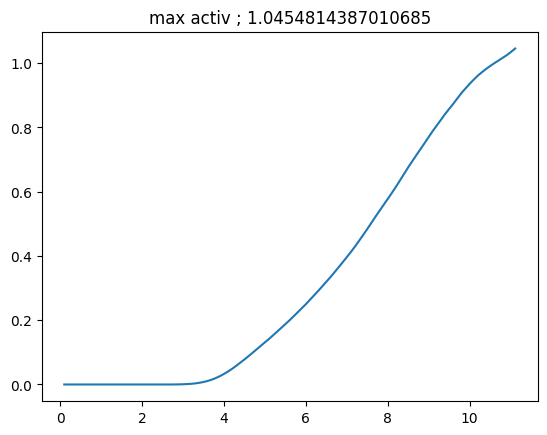

In [116]:
import matplotlib.pyplot as plt

plt.plot(tvec, e_activs)
plt.title(f"max activ ; {e_activs[-1]}")